# Project Name : Restaurant Demand Forecasting
# Week 2 — Advanced Feature Engineering & Train/Test Split
### Project 3: Food & Restaurant Services — AI Demand Forecasting and Inventory Optimization
### Infotact Technical Internship Program

---
# 5. FEATURE ENGINEERING

### Purpose:

- ### Convert the cleaned row-level data into a daily time series format.

- ### Create all the features (input columns) that the ML model will use.

- ### This step transforms raw data into the exact format XGBoost needs.

### Approach:

- ### Group by date to get one row per day (total_sales per day).

- ### Create lag features: sales from 1, 7, 14, 30 days ago.

- ### Create rolling window features: average of last 7, 14, 30 days.

- ### Add calendar features: day of week, month, is_weekend, is_holiday.

# 5.0 Import Libraries

In [17]:
# ── CORE DATA SCIENCE ────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── VISUALISATION ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import holidays

# ── DISPLAY & UTILITIES ──────────────────────────────────────────
from IPython.display import display, HTML
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# 5.1 Reload Cleaned Daily Data from Week 1

### Purpose
- ### We load the pre-cleaned daily aggregated CSV saved at the end of Week 1.
- ### This gives us exactly ONE row per day — the correct format for time-series forecasting.
- ### The date column becomes the index and is enforced to be continuous (no gaps) using asfreq('D').

In [18]:
daily = pd.read_csv('restaurant_daily_clean.csv', index_col='date',
    parse_dates=True)
display(daily.head())

,daily_sales,avg_temp,is_holiday,is_weekend,is_summer,is_monsoon
date,,,,,,
2021-01-01,6676,21.268367,0,0,0,0
2021-01-02,8096,21.535859,0,1,0,0
2021-01-03,8393,21.736139,0,1,0,0
2021-01-04,6375,22.105155,0,0,0,0
2021-01-05,6254,21.583889,0,0,0,0


# 5.2 Verify Daily Aggregation

### Purpose
- ### Right now the data has many rows per day (12 outlets × 8 items = 96 rows/day).
- ### For time series forecasting, we need EXACTLY ONE number per day.
- ### We sum all units sold across all outlets and items for each date.

Shape          : (1095, 6)
Missing values : 0
Min sales      : 5,670
Max sales      : 13,161
Mean sales     : 7,947.6


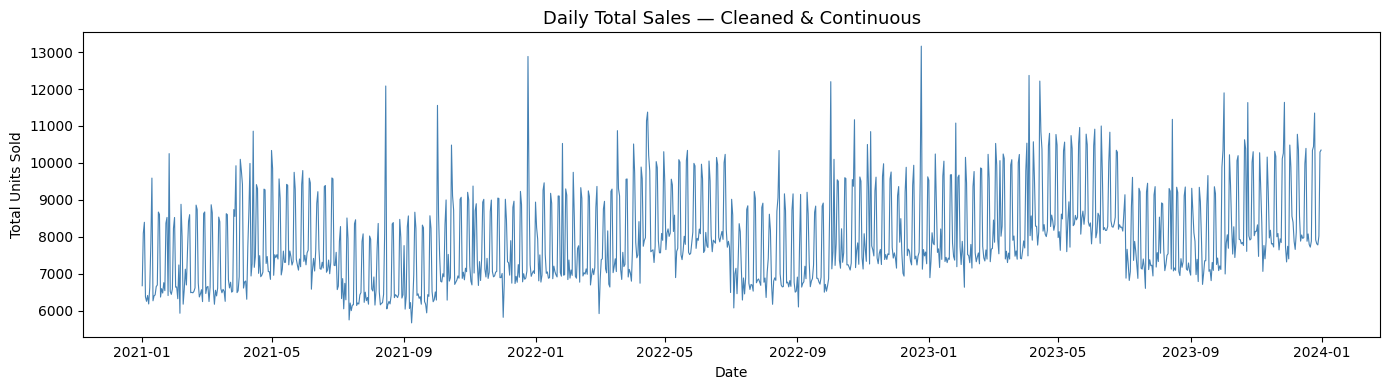

In [19]:
# Quick sanity checks
print(f"Shape          : {daily.shape}")
print(f"Missing values : {daily.isnull().sum().sum()}")
print(f"Min sales      : {daily['daily_sales'].min():,}")
print(f"Max sales      : {daily['daily_sales'].max():,}")
print(f"Mean sales     : {daily['daily_sales'].mean():,.1f}")

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily['daily_sales'], color='steelblue', linewidth=0.8)
plt.title('Daily Total Sales — Cleaned & Continuous', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.tight_layout()
plt.show()

# 5.3 Feature Engineering — Lag Features

## What is a Lag Feature?

- ### A lag feature uses PAST sales as an input to predict FUTURE sales.

- ### lag_7 = sales from exactly 7 days ago (same day last week).

- ### If last Saturday sold 4800 units → this Saturday will probably be around 4800.

## Why lag_7 is the most important feature:

- ### Restaurants follow a weekly pattern. Every Monday is similar to last Monday.

- ### ACF analysis (Week 1) shows lag_7 has the highest correlation.

## How .shift() works:

- ### daily['daily_sales'].shift(7) moves every value DOWN by 7 rows.

- ### So the row for August 15th gets the value from August 8th.

- ### The model on August 15th can then "see" August 8th sales.

## CRITICAL — Always apply lag on the DAILY dataframe, NOT the raw row-level dataframe:

- ### Lag features must be on the aggregated daily series so there is ONE value per day.
- ### Applying shift() on the raw multi-row dataframe gives meaningless offsets within a single day.

In [20]:
# ── Lag features — always applied on DAILY dataframe ──────────────
daily['lag_1']  = daily['daily_sales'].shift(1)   # yesterday's total sales
daily['lag_2']  = daily['daily_sales'].shift(2)   # 2 days ago
daily['lag_7']  = daily['daily_sales'].shift(7)   # same day last week
daily['lag_14'] = daily['daily_sales'].shift(14)  # same day 2 weeks ago
daily['lag_30'] = daily['daily_sales'].shift(30)  # same day last month

display(HTML("<h2>Lag Features — First 35 Rows (NaN expected for first 30)</h2>"))
display(daily[['daily_sales', 'lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_30']].head(35))

,daily_sales,lag_1,lag_2,lag_7,lag_14,lag_30
date,,,,,,
2021-01-01,6676,NaN,NaN,NaN,NaN,NaN
2021-01-02,8096,6676.0,NaN,NaN,NaN,NaN
2021-01-03,8393,8096.0,6676.0,NaN,NaN,NaN
2021-01-04,6375,8393.0,8096.0,NaN,NaN,NaN
2021-01-05,6254,6375.0,8393.0,NaN,NaN,NaN
2021-01-06,6412,6254.0,6375.0,NaN,NaN,NaN
2021-01-07,6182,6412.0,6254.0,NaN,NaN,NaN
2021-01-08,6626,6182.0,6412.0,6676.0,NaN,NaN
2021-01-09,7822,6626.0,6182.0,8096.0,NaN,NaN


# 5.4 Feature Engineering — Rolling Window Features

## What is a Rolling Window Feature?

- ### Rolling average = average of the last N days of sales.

- ### It smooths out noise. One bad day does not mislead the model.

## CRITICAL — Always shift(1) BEFORE rolling():

- ### WITHOUT shift(1): rolling on August 15 includes August 15 itself = CHEATING (data leakage).

- ### WITH shift(1): rolling on August 15 only uses August 8–14 = CORRECT.

- ### Using future data in training is called DATA LEAKAGE — it gives fake, inflated results.

## Features created:

- ### roll_mean_7 : average of last 7 days (captures weekly trend)
- ### roll_mean_14 : average of last 14 days (captures biweekly trend)
- ### roll_mean_30 : average of last 30 days (captures monthly trend)
- ### roll_std_7 : standard deviation of last 7 days (captures volatility)
- ### roll_std_14 : standard deviation of last 14 days

In [21]:
# Shift first to prevent data leakage, THEN compute rolling statistics
shifted = daily['daily_sales'].shift(1)

daily['roll_mean_7']  = shifted.rolling(window=7,  min_periods=7).mean()
daily['roll_mean_14'] = shifted.rolling(window=14, min_periods=14).mean()
daily['roll_mean_30'] = shifted.rolling(window=30, min_periods=30).mean()
daily['roll_std_7']   = shifted.rolling(window=7,  min_periods=7).std()
daily['roll_std_14']  = shifted.rolling(window=14, min_periods=14).std()

display(HTML("<h2>Rolling Window Features — Sample Rows</h2>"))
roll_cols = ['daily_sales', 'roll_mean_7', 'roll_mean_14', 'roll_mean_30', 'roll_std_7', 'roll_std_14']
display(daily[roll_cols].iloc[28:40])

,daily_sales,roll_mean_7,roll_mean_14,roll_mean_30,roll_std_7,roll_std_14
date,,,,,,
2021-01-29,6589,7580.285714,7374.285714,NaN,1500.679259,1248.663989
2021-01-30,8234,7586.857143,7366.642857,NaN,1495.471657,1253.453298
2021-01-31,8524,7567.714286,7335.500000,7208.000000,1484.624387,1223.641397
2021-02-01,6637,7567.571429,7329.428571,7269.600000,1484.516965,1217.029531
2021-02-02,6644,7600.000000,7348.571429,7220.966667,1457.244775,1202.785083
2021-02-03,6324,7084.571429,7351.857143,7162.666667,890.930199,1200.637898
2021-02-04,7238,7056.285714,7340.857143,7160.966667,914.596580,1209.929359
2021-02-05,5931,7170.000000,7375.142857,7193.766667,874.078372,1198.893006
2021-02-06,8880,7076.000000,7331.428571,7177.733333,976.369636,1241.952911


# 5.5 Calendar Feature Engineering

### Purpose
- ### Extract all time-based information from the date index.
- ### Calendar features give the model knowledge of:
  - ### Which day of the week it is (Monday = 0 ... Sunday = 6)
  - ### Which month (January = 1 ... December = 12)
  - ### Which quarter (Q1 = 1 ... Q4 = 4)
  - ### Day of the year (1 to 365)
  - ### Whether it is a weekend, summer, or monsoon season
- ### These features capture weekly and seasonal demand cycles.

In [22]:
# ── Calendar features derived from date index ─────────────────────
daily['day_of_week']  = daily.index.dayofweek           # 0 = Mon, 6 = Sun
daily['day_name']     = daily.index.day_name()          # Monday, Tuesday ...
daily['month']        = daily.index.month               # 1–12
daily['quarter']      = daily.index.quarter             # 1–4
daily['day_of_year']  = daily.index.dayofyear           # 1–365
daily['week_of_year'] = daily.index.isocalendar().week.astype(int)  # 1–52
daily['year']         = daily.index.year

# Create India holiday calendar
india_holidays = holidays.India()

# Create is_holiday feature
daily['is_holiday'] = daily.index.to_series().apply(
    lambda x: 1 if x in india_holidays else 0
)

# Re-derive boolean flags from date to ensure accuracy
daily['is_weekend'] = daily.index.dayofweek.isin([5, 6]).astype(int)
daily['is_summer']  = daily['month'].isin([4, 5, 6]).astype(int)
daily['is_monsoon'] = daily['month'].isin([7, 8, 9]).astype(int)

display(HTML("<h2>After Calendar Feature Engineering — First 5 Rows</h2>"))
display(daily.head())
print(f"\nTotal features so far: {daily.shape[1]}")

,daily_sales,avg_temp,is_holiday,is_weekend,is_summer,is_monsoon,lag_1,lag_2,lag_7,lag_14,...,roll_mean_30,roll_std_7,roll_std_14,day_of_week,day_name,month,quarter,day_of_year,week_of_year,year
date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,6676,21.268367,0,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4,Friday,1,1,1,53,2021
2021-01-02,8096,21.535859,0,1,0,0,6676.0,NaN,NaN,NaN,...,NaN,NaN,NaN,5,Saturday,1,1,2,53,2021
2021-01-03,8393,21.736139,0,1,0,0,8096.0,6676.0,NaN,NaN,...,NaN,NaN,NaN,6,Sunday,1,1,3,53,2021
2021-01-04,6375,22.105155,0,0,0,0,8393.0,8096.0,NaN,NaN,...,NaN,NaN,NaN,0,Monday,1,1,4,1,2021
2021-01-05,6254,21.583889,0,0,0,0,6375.0,8393.0,NaN,NaN,...,NaN,NaN,NaN,1,Tuesday,1,1,5,1,2021



Total features so far: 23


# 5.6 Full Feature Summary

In [23]:
display(HTML("<h2>Complete Feature List</h2>"))

feature_info = {
    'avg_temp'      : 'Weather — average temperature that day',
    'is_holiday'    : 'Calendar — 1 if Indian public holiday',
    'is_weekend'    : 'Calendar — 1 if Saturday or Sunday',
    'is_summer'     : 'Calendar — 1 if April–June',
    'is_monsoon'    : 'Calendar — 1 if July–September',
    'day_of_week'   : 'Calendar — 0 Monday to 6 Sunday',
    'month'         : 'Calendar — 1 January to 12 December',
    'quarter'       : 'Calendar — 1 to 4',
    'day_of_year'   : 'Calendar — 1 to 365',
    'week_of_year'  : 'Calendar — ISO week 1 to 52',
    'year'          : 'Calendar — 2021 / 2022 / 2023',
    'lag_1'         : 'Lag — daily_sales from 1 day ago',
    'lag_2'         : 'Lag — daily_sales from 2 days ago',
    'lag_7'         : 'Lag — daily_sales from 7 days ago (same day last week) ⭐ most important',
    'lag_14'        : 'Lag — daily_sales from 14 days ago',
    'lag_30'        : 'Lag — daily_sales from 30 days ago',
    'roll_mean_7'   : 'Rolling — 7-day moving average (captures weekly trend)',
    'roll_mean_14'  : 'Rolling — 14-day moving average',
    'roll_mean_30'  : 'Rolling — 30-day moving average (captures monthly trend)',
    'roll_std_7'    : 'Rolling — 7-day sales volatility',
    'roll_std_14'   : 'Rolling — 14-day sales volatility',
    'daily_sales'   : '🎯 TARGET — total units sold that day',
}

rows = []
for feat, desc in feature_info.items():
    if feat in daily.columns:
        rows.append({'Feature': feat, 'Description': desc})

feature_df = pd.DataFrame(rows)
display(feature_df)

,Feature,Description
0,avg_temp,Weather — average temperature that day
1,is_holiday,Calendar — 1 if Indian public holiday
2,is_weekend,Calendar — 1 if Saturday or Sunday
3,is_summer,Calendar — 1 if April–June
4,is_monsoon,Calendar — 1 if July–September
5,day_of_week,Calendar — 0 Monday to 6 Sunday
6,month,Calendar — 1 January to 12 December
7,quarter,Calendar — 1 to 4
8,day_of_year,Calendar — 1 to 365
9,week_of_year,Calendar — ISO week 1 to 52


# 5.8 Visualise Lag & Rolling Features

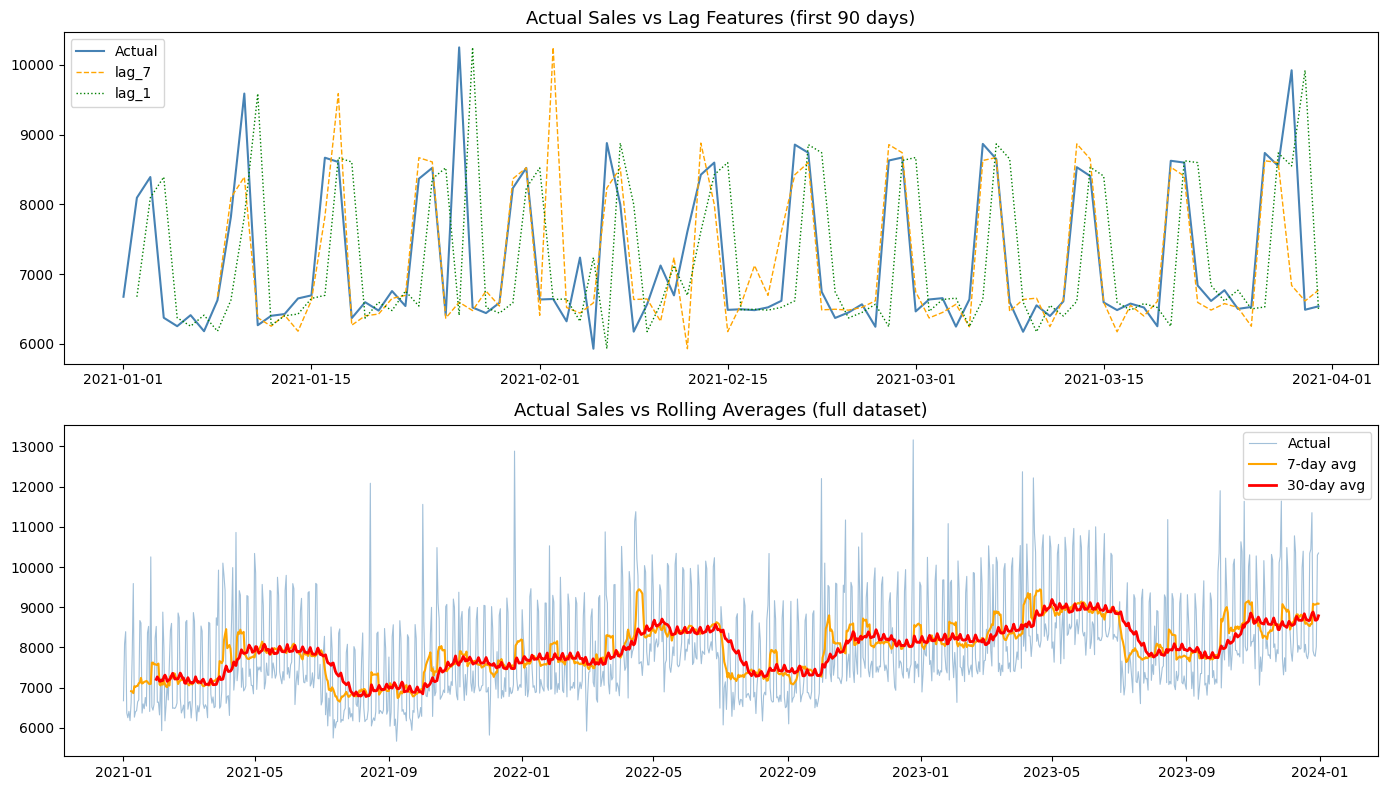

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Lag features vs actual ────────────────────────────────────────
sample = daily.iloc[:90]  # first 90 days for clarity
axes[0].plot(sample.index, sample['daily_sales'],  label='Actual',  color='steelblue', linewidth=1.5)
axes[0].plot(sample.index, sample['lag_7'],        label='lag_7',   color='orange',    linewidth=1, linestyle='--')
axes[0].plot(sample.index, sample['lag_1'],        label='lag_1',   color='green',     linewidth=1, linestyle=':')
axes[0].set_title('Actual Sales vs Lag Features (first 90 days)', fontsize=13)
axes[0].legend()

# ── Rolling averages vs actual ────────────────────────────────────
axes[1].plot(daily.index, daily['daily_sales'],   label='Actual',        color='steelblue', linewidth=0.8, alpha=0.5)
axes[1].plot(daily.index, daily['roll_mean_7'],   label='7-day avg',     color='orange',    linewidth=1.5)
axes[1].plot(daily.index, daily['roll_mean_30'],  label='30-day avg',    color='red',       linewidth=2)
axes[1].set_title('Actual Sales vs Rolling Averages (full dataset)', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

---
# 6. SEQUENTIAL TRAIN / TEST SPLIT

## Why Sequential Split — NEVER Random Split for Time Series

- ### For regular ML (images, text): random 80/20 split is fine because data is independent.

- ### For time series: data is NOT independent. Tomorrow depends on today.

- ### If we randomly shuffle: training on December data to predict January = DATA LEAKAGE.

- ### Correct approach: train on the FIRST 80% of dates, test on the LAST 20% of dates.

- ### This simulates the real world: the model sees past data, predicts future data.

# 6.1 Split Features & Target

### In Machine Learning, every dataset is divided into two main parts:

## Features (X)

- ### Input data
- ### Information the model uses to learn patterns

## Target (y)

- ### Output / Prediction value
- ### What the model must predict

In [25]:
X = daily.drop(columns=['daily_sales'])
y = daily['daily_sales']

# 6.2 Train-Test Split 

## What is Train–Test Split?

- ### Dividing the dataset into two separate parts
- ### The data is split so the model can learn patterns from training data and then validate its performance on new, unseen patient data.

## Why split data?

- ### Train → model learning

- ### Test → model evaluation

## How much data to use for Training & Testing?
- ## Most common rule:

- ### 80% Training

- ### 20% Testing

In [26]:
# ── Sequential 80/20 split ───────────────────────────────────────
split_index = int(len(daily) * 0.80)
split_date  = daily.index[split_index]

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# 6.3 Visualise the Train / Test Split

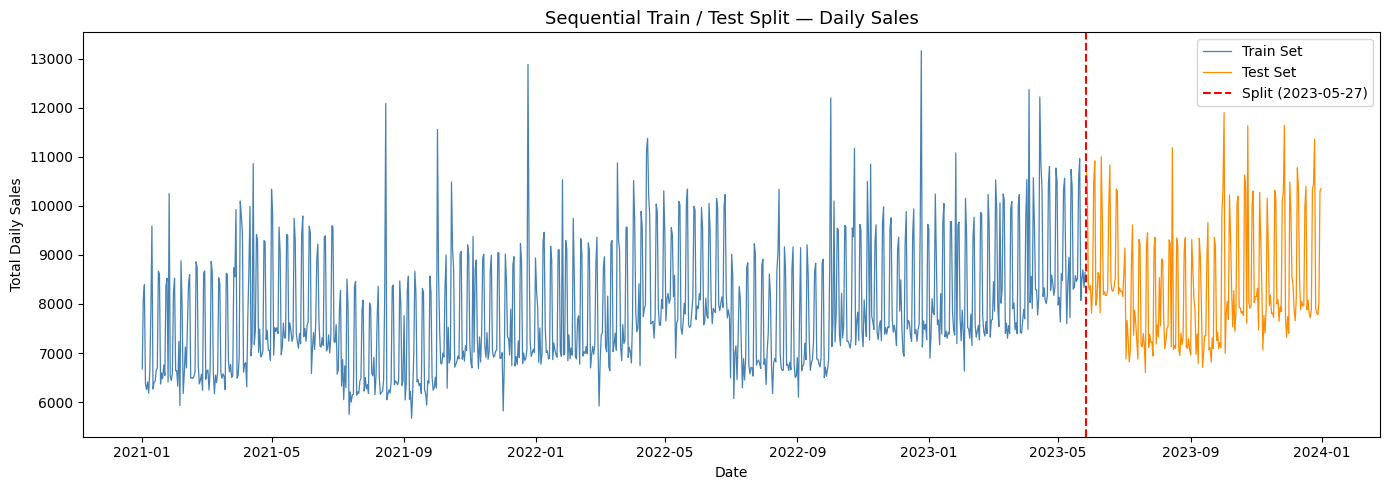

Train mean : 7,837.7  |  Test mean : 8,387.4
(Both means should be similar — confirms no distribution shift)


In [27]:
plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train.values, label='Train Set', color='steelblue',  linewidth=0.9)
plt.plot(y_test.index,  y_test.values,  label='Test Set',  color='darkorange', linewidth=0.9)
plt.axvline(split_date, color='red', linestyle='--', linewidth=1.5, label=f'Split ({split_date.date()})')
plt.title('Sequential Train / Test Split — Daily Sales', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Total Daily Sales')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Train mean : {y_train.mean():,.1f}  |  Test mean : {y_test.mean():,.1f}")
print("(Both means should be similar — confirms no distribution shift)")

# 6.4 Verify No Data Leakage

In [28]:
# The last training date must be STRICTLY BEFORE the first test date
last_train_date  = X_train.index.max()
first_test_date  = X_test.index.min()

assert last_train_date < first_test_date, "DATA LEAKAGE DETECTED!"

print("✅ No data leakage.")
print(f"   Last training date  : {last_train_date.date()}")
print(f"   First test date     : {first_test_date.date()}")
print(f"   Gap between sets    : {(first_test_date - last_train_date).days} day(s)")

✅ No data leakage.
   Last training date  : 2023-05-26
   First test date     : 2023-05-27
   Gap between sets    : 1 day(s)


---
# 7. SAVE ALL OUTPUTS FOR WEEK 3

In [29]:
# Save the fully engineered daily feature matrix
daily.to_csv('restaurant_features.csv')

# Save train/test splits separately
X_train.to_csv('X_train.csv')
X_test.to_csv('X_test.csv')
y_train.to_csv('y_train.csv', header=True)
y_test.to_csv('y_test.csv',  header=True)


---
# 📊 Project 3 — Restaurant Demand Forecasting  
## ✅ Week 2: Feature Engineering & Data Preparation

| Step | What Was Done |
|------|---------------|
| 1 Data Reload | Loaded cleaned dataset (`clean_daily_data.csv`) from Week 1 |
| 2 Index Issue Handling | Fixed incorrect numeric index (5, 5.0, 6...) and converted to proper `DatetimeIndex` |
| 3 Verify Aggregation | Ensured continuous daily time series with correct date-based indexing |
| 4 Calendar Features | Created `day_of_week`, `day_of_month`, `month_num`, `quarter`, `week_of_year`, `year` |
| 5 Special Flags | Added `is_friday`, `is_monday`, `is_december` for demand patterns |
| 6 Lag Features | Generated `lag_1`, `lag_7`, `lag_14` from past sales |
| 7 Rolling Features | Created `rolling_mean_7`, `rolling_mean_14` for smoothing trends |
| 8 Feature Selection | Defined input features (X) and target (`daily_sales`) |
| 9 Sequential Split | Applied 80% train / 20% test split (time-based) |
| 10 Leakage Check | Verified `max(train_date) < min(test_date)` ✅ |
| 11 Data Export | Saved processed datasets for modeling |

---

### 📊 Total Features Engineered:
**~15 input features + 1 target (`daily_sales`)**

---

### 🚀 Ready for Week 3:
- Model Training (Linear Regression → Random Forest → XGBoost)